In [1]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection 
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('../exports/login_and_user_management.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.8oss0ybm44rk9qstbv2er3xu3.fp5afyx2euyn0bvpdlwu72ujt'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.eaxfwhx09aj4komi6zsd3ewhj.a3rcv78uhac2a0q953xjf2dhz'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.r74oogu6jmq0vh03nkm5i6i26.npja9wayckua1k62pd0dl6ykb'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.x4tglh5k2fh3tulf079kq1ynf.bogrfv2by8uf4d78x16fdh4r5'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-eda_elasticsearch.1.tdfgqdx1hv0cmdtcllg8augv6'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.1.5n71nnpv2rm6m0idd82nozx8h'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-eda_kafka.1.mwwlyw1o6g834e8d5jz5q6n3a'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-eda_node-exporter.8oss0ybm44rk9qstbv2er3xu3.mkonoq8ggxtkj1e6li7j2h6oc'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-eda_node-exporter.eaxfwhx09aj4komi6zsd3ewhj.cu5yoildjo6i64x4vrmx5ybul'},...,mem_by_svc__series_11 {'container_label_com_docker_swarm_task_name': 'chat-eda_postgres-exporter.1.cpfheuq6uvv6qkncvyhlerevz'},mem_by_svc__series_12 {'container_label_com_docker_swarm_task_name': 'chat-eda_postgres.1.l14bl4s1rr8bbu5d594c1133t'},mem_by_svc__series_13 {'container_label_com_docker_swarm_task_name': 'chat-eda_prometheus.1.rwgb5wlqm14s508ctihttxu4n'},mem_by_svc__series_14 {'container_label_com_docker_swarm_task_name': 'chat-eda_search-service.1.gf47lpml0f9z6sxgbcbfr5ywf'},mem_by_svc__series_15 {'container_label_com_docker_swarm_task_name': 'chat-eda_user-service.1.glyp2eq8tyn4vzpzphg9l6r4v'},mem_by_svc__series_16 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.1.tlm06e6egabxl3lzw4cxo37wo'},mem_by_svc__series_17 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.2.6ykxemp8cx3tre5loyt66bm7g'},mem_by_svc__series_18 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.y6wd00l3n4xtv9gtnlk3rczd0'},k6_users__series_0 {},http_rt_latency__series_0 {}
0,2026-04-20 15:00:50.605000019+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,46161920.0,55488512.0,NaN,5.704663e+08,NaN,248954880.0,263147520.0,NaN,NaN
1,2026-04-20 15:00:55.605000019+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8208384.0,46161920.0,55488512.0,NaN,5.704663e+08,256135168.0,248954880.0,263147520.0,NaN,NaN
2,2026-04-20 15:01:00.605000019+00:00,0.006950,0.005877,NaN,0.009545,NaN,0.000000,0.013893,0.000709,0.000677,...,8208384.0,46178304.0,108605440.0,133763072.0,1.180643e+09,256135168.0,249229312.0,263290880.0,NaN,NaN
3,2026-04-20 15:01:05.605000019+00:00,0.009165,0.007445,0.015823,0.012635,0.292317,0.000000,0.018548,0.000922,0.000859,...,8220672.0,46178304.0,108605440.0,133763072.0,1.180643e+09,256421888.0,249229312.0,263290880.0,NaN,NaN
4,2026-04-20 15:01:10.605000019+00:00,0.011833,0.009464,0.020365,0.014569,0.371002,0.000000,0.021385,0.001105,0.000962,...,8220672.0,47210496.0,116641792.0,209338368.0,1.694278e+09,256421888.0,249229312.0,263561216.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2026-04-20 15:14:15.605000019+00:00,0.025716,0.029797,0.057342,0.034697,0.714442,0.155065,0.022526,0.001675,0.003625,...,8126464.0,51408896.0,186544128.0,394391552.0,5.767168e+08,274685952.0,264777728.0,276762624.0,86.0,0.045317
162,2026-04-20 15:14:20.605000019+00:00,0.025382,0.030219,0.057342,0.034879,0.714442,0.154955,0.022408,0.001706,0.003517,...,8126464.0,50388992.0,186630144.0,394465280.0,5.768397e+08,274685952.0,264781824.0,276824064.0,87.0,0.045253
163,2026-04-20 15:14:25.605000019+00:00,0.025382,0.030219,0.059569,0.034879,0.719803,0.154972,0.023373,0.001706,0.003517,...,7954432.0,50388992.0,186630144.0,394465280.0,5.768397e+08,274690048.0,264781824.0,2

=== Summary over selected window (CSV) ===
VM CPU-like (sum by svc): mean=1.600  max=2.709
App CPU (user-service/app): mean=0.318  max=1.780
DB commits/s: NOT PRESENT in login_and_user_management.csv


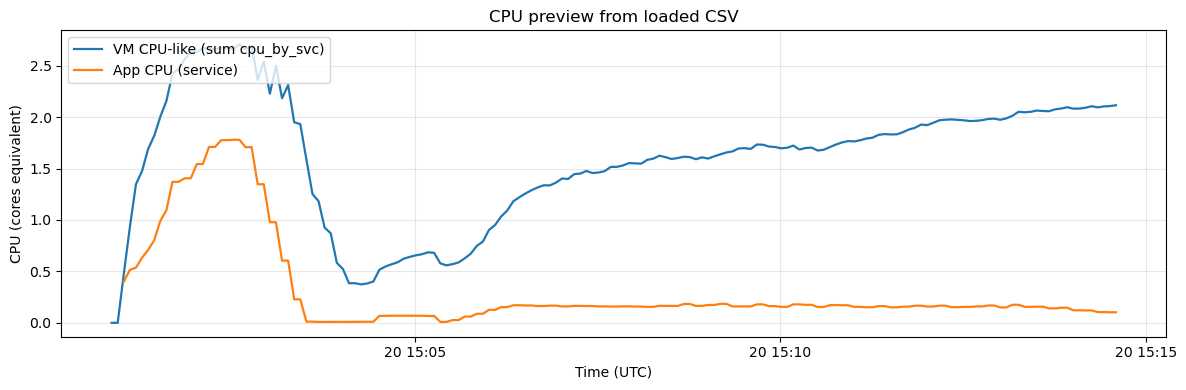

In [3]:
# Build summary/preview directly from loaded CSV (no Prometheus queries).
wide_df = df.copy()
if "timestamp" in wide_df.columns:
    wide_df = wide_df.set_index("timestamp")
wide_df.index = pd.to_datetime(wide_df.index, utc=True, errors="coerce")
wide_df = wide_df[~wide_df.index.isna()].sort_index()

cpu_cols = [c for c in wide_df.columns if str(c).lower().startswith("cpu_by_svc__")]
vm_cpu = wide_df[cpu_cols].sum(axis=1) if cpu_cols else None
app_cpu = next((wide_df[c] for c in wide_df.columns if "cpu_by_svc__" in str(c).lower() and ("user-service.1" in str(c).lower() or "app.1" in str(c).lower())), None)
commits = None  # commit metric is not in this export CSV schema

print("=== Summary over selected window (CSV) ===")
if vm_cpu is not None:
    print(f"VM CPU-like (sum by svc): mean={vm_cpu.mean():.3f}  max={vm_cpu.max():.3f}")
else:
    print("VM CPU-like: NO DATA")

if app_cpu is not None:
    print(f"App CPU (user-service/app): mean={app_cpu.mean():.3f}  max={app_cpu.max():.3f}")
else:
    print("App CPU: NO DATA")

if commits is not None:
    print(f"DB commits/s: mean={commits.mean():.2f}  max={commits.max():.2f}")
else:
    print("DB commits/s: NOT PRESENT in login_and_user_management.csv")

fig, ax = plt.subplots(figsize=(12, 4))
if vm_cpu is not None:
    ax.plot(vm_cpu.index, vm_cpu.values, label="VM CPU-like (sum cpu_by_svc)", lw=1.6)
if app_cpu is not None:
    ax.plot(app_cpu.index, app_cpu.values, label="App CPU (service)", lw=1.6)

ax.set_title("CPU preview from loaded CSV")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("CPU (cores equivalent)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [4]:
# Build chart inputs from loaded CSV (no Prometheus queries).
wide_df = df.copy()
if "timestamp" in wide_df.columns:
    wide_df = wide_df.set_index("timestamp")
wide_df.index = pd.to_datetime(wide_df.index, utc=True, errors="coerce")
wide_df = wide_df[~wide_df.index.isna()].sort_index()


def _pick_series(candidates):
    lower_cols = {str(c).lower(): c for c in wide_df.columns}
    for token in candidates:
        token_l = token.lower()
        for lc, orig in lower_cols.items():
            if token_l in lc:
                return wide_df[orig].dropna()
    return None


def _pick_many(prefix):
    return [c for c in wide_df.columns if str(c).lower().startswith(prefix.lower())]


cpu_cols = _pick_many("cpu_by_svc__")
vm_cpu_cores_s = wide_df[cpu_cols].sum(axis=1) if cpu_cols else None
pg_cpu_cores_s = _pick_series(["cpu_by_svc", "postgres.1"])
java_cpu_cores_s = _pick_series(["cpu_by_svc", "user-service.1", "app.1"])
k6_users_s = _pick_series(["k6_users__", "k6_vus"])
http_rt_latency_s = _pick_series(["http_rt_latency__", "http_req_duration", "latency"])


def _to_frame(s):
    return s.to_frame(name=str(s.name)) if s is not None else pd.DataFrame(index=wide_df.index)


vm_cpu_cores = _to_frame(vm_cpu_cores_s)
pg_cpu_cores = _to_frame(pg_cpu_cores_s)
java_cpu_cores = _to_frame(java_cpu_cores_s)
k6_users = _to_frame(k6_users_s)
http_rt_latency = _to_frame(http_rt_latency_s)

cores = float(vm_cpu_cores.iloc[:, 0].max()) if not vm_cpu_cores.empty else 1.0

print("Selected columns from loaded CSV:")
print("- vm_cpu_cores:", list(vm_cpu_cores.columns) if not vm_cpu_cores.empty else "NOT FOUND")
print("- pg_cpu_cores:", list(pg_cpu_cores.columns) if not pg_cpu_cores.empty else "NOT FOUND")
print("- java_cpu_cores:", list(java_cpu_cores.columns) if not java_cpu_cores.empty else "NOT FOUND")
print("- k6_users:", list(k6_users.columns) if not k6_users.empty else "NOT FOUND")
print("- http_rt_latency:", list(http_rt_latency.columns) if not http_rt_latency.empty else "NOT FOUND")

Selected columns from loaded CSV:
- vm_cpu_cores: ['None']
- pg_cpu_cores: ["cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.8oss0ybm44rk9qstbv2er3xu3.fp5afyx2euyn0bvpdlwu72ujt'}"]
- java_cpu_cores: ["cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.8oss0ybm44rk9qstbv2er3xu3.fp5afyx2euyn0bvpdlwu72ujt'}"]
- k6_users: ['k6_users__series_0 {}']
- http_rt_latency: ['http_rt_latency__series_0 {}']


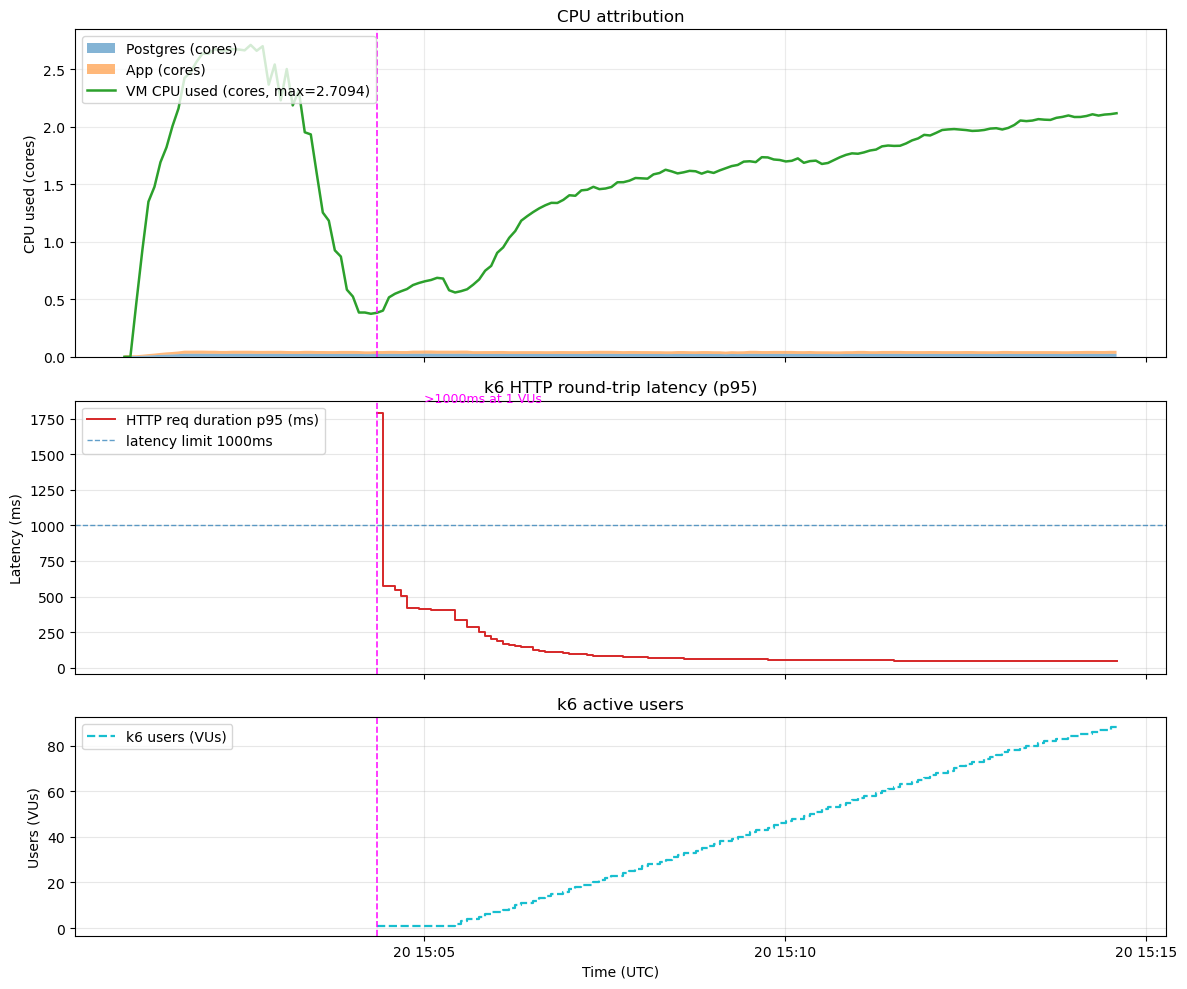

First HTTP p95 > 1000 ms at: 2026-04-20 15:04:20.605000019+00:00
Latency at crossing: 1790.97 ms
k6 users near crossing: 1


In [5]:
# ---- CPU chart data prep ----
s_vm = vm_cpu_cores.iloc[:, 0] if not vm_cpu_cores.empty else None
s_app = java_cpu_cores.iloc[:, 0] if not java_cpu_cores.empty else None
s_pg = pg_cpu_cores.iloc[:, 0] if not pg_cpu_cores.empty else None

df = pd.concat(
    [x.rename(n) for x, n in [(s_vm, "vm"), (s_pg, "postgres"), (s_app, "app")] if x is not None],
    axis=1
).interpolate(limit_direction="both")

# ---- 3 rows: CPU (top), HTTP latency (middle), k6 users (bottom) ----
fig, (ax_cpu, ax_lat, ax_k6) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 0.8]}
)

# ========== TOP: CPU attribution ==========
ax_cpu.stackplot(
    df.index,
    df["postgres"] if "postgres" in df else 0,
    df["app"] if "app" in df else 0,
    labels=["Postgres (cores)", "App (cores)"],
    alpha=0.55,
)

if not vm_cpu_cores.empty:
    s = vm_cpu_cores.iloc[:, 0]
    ax_cpu.plot(s.index, s.values, lw=1.8, label=f"VM CPU used (cores, max={cores:g})")

ax_cpu.set_title("CPU attribution")
ax_cpu.set_ylabel("CPU used (cores)")
ax_cpu.grid(True, alpha=0.25)
ax_cpu.legend(loc="upper left")

# ========== MIDDLE: HTTP latency ==========
cross_ts = None
cross_val_ms = None

if not http_rt_latency.empty:
    s = http_rt_latency.iloc[:, 0] * 1000  # seconds -> ms
    ax_lat.step(
        s.index, s.values, where="post",
        color="tab:red", linewidth=1.4,
        label="HTTP req duration p95 (ms)"
    )

    # first point where latency exceeds 1000ms
    crossed = s[s > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])
else:
    ax_lat.text(
        0.5, 0.5, "No data in http_rt_latency",
        ha="center", va="center", transform=ax_lat.transAxes
    )

ax_lat.axhline(
    1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7,
    label="latency limit 1000ms"
)
ax_lat.set_title("k6 HTTP round-trip latency (p95)")
ax_lat.set_ylabel("Latency (ms)")
ax_lat.grid(True, alpha=0.3)

# ========== BOTTOM: k6 users ==========
if not k6_users.empty:
    s_u = k6_users.iloc[:, 0]
    ax_k6.step(
        s_u.index, s_u.values, where="post",
        color="tab:cyan", lw=1.6, linestyle="--", label="k6 users (VUs)"
    )
else:
    ax_k6.text(
        0.5, 0.5, "No data in k6_users",
        ha="center", va="center", transform=ax_k6.transAxes
    )

ax_k6.set_title("k6 active users")
ax_k6.set_xlabel("Time (UTC)")
ax_k6.set_ylabel("Users (VUs)")
ax_k6.grid(True, alpha=0.3)

# ========== Vertical marker on all subplots ==========
if cross_ts is not None:
    for ax in (ax_cpu, ax_lat, ax_k6):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)

    s_u = k6_users.iloc[:, 0]
    nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
    users_at_cross = float(s_u.iloc[nearest_idx])
    ax_lat.annotate(
        f"         >1000ms at {users_at_cross:.0f} VUs",
        xy=(cross_ts, cross_val_ms),
        xytext=(8, 8),
        textcoords="offset points",
        color="magenta",
        fontsize=9
    )

# legends after adding lines
ax_lat.legend(loc="upper left")
ax_k6.legend(loc="upper left")

plt.tight_layout()
plt.show()

# ---- print threshold crossing info ----
if cross_ts is None:
    print("HTTP p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First HTTP p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")

    # optional: k6 users at crossing (nearest timestamp)
    if not k6_users.empty:
        s_u = k6_users.iloc[:, 0]
        nearest_idx = s_u.index.get_indexer([cross_ts], method="nearest")[0]
        users_at_cross = float(s_u.iloc[nearest_idx])
        print(f"k6 users near crossing: {users_at_cross:.0f}")